<a href="https://colab.research.google.com/github/maithili39/AI/blob/main/ModelBuilding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("/content/Salary_Dataset_DataScienceLovers.csv")

In [6]:
df.isnull().sum()

,0
Rating,0
Company Name,1
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [7]:
for column in df.columns:
  if df[column].dtype == 'object':
    # Fill missing object values with the mode of the column
    df[column] = df[column].fillna(df[column].mode()[0])
  else:
    # Fill missing numeric values with the mean of the column
    df[column] = df[column].fillna(df[column].mean())
print(df.isnull().sum())

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64


In [8]:
df.isnull().sum()

,0
Rating,0
Company Name,0
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
label_encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object' and column != 'Salary': # Apply LabelEncoder only to object type columns, excluding 'Salary'
        df[column] = label_encoder.fit_transform(df[column])

print(df.head())

   Rating  Company Name  Job Title   Salary  Salaries Reported  Location  \
0     3.8          8129         28   400000                  3         0   
1     4.5           417         28   400000                  3         0   
2     4.0          9777         28  1000000                  3         0   
3     3.8          8533         28   300000                  3         0   
4     4.4           884         28   600000                  3         0   

   Employment Status  Job Roles  
0                  1          0  
1                  1          0  
2                  1          0  
3                  1          0  
4                  1          0  


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X= df.drop('Salary',axis=1)
y=df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
# Initialize models
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)

models = {"Decision Tree": dt_model, "Random Forest": rf_model}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} - Mean Squared Error: {mse:.4f}")
    print(f"{name} - R-squared: {r2:.4f}")

# Display results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison Results ---")
display(results_df)


Training Decision Tree...
Decision Tree - Mean Squared Error: 2484415021401.0435
Decision Tree - R-squared: -5.1269

Training Random Forest...
Random Forest - Mean Squared Error: 623993827858.3008
Random Forest - R-squared: -0.5389

--- Model Comparison Results ---


,MSE,R2
Decision Tree,2.484415e+12,-5.126940
Random Forest,6.239938e+11,-0.538862


/tmp/ipykernel_3819/3911350832.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MSE', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_3819/3911350832.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[1], palette='magma')


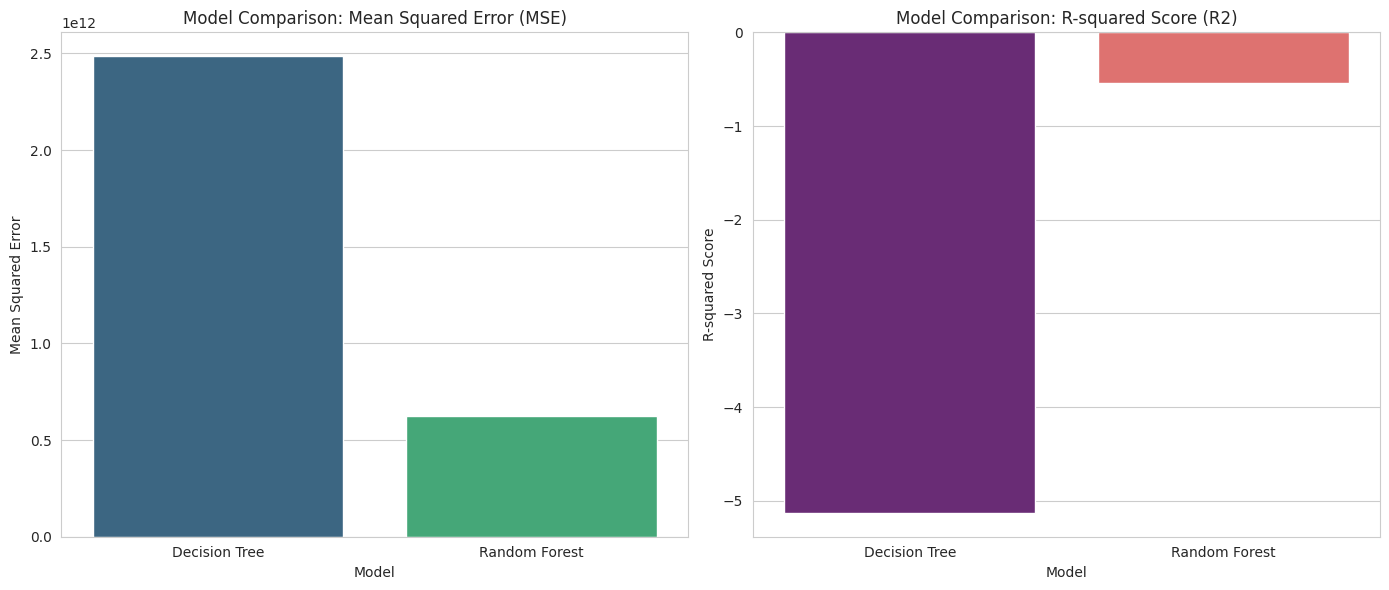

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot MSE
sns.barplot(x=results_df.index, y='MSE', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: Mean Squared Error (MSE)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Mean Squared Error')

# Plot R2 Score
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison: R-squared Score (R2)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R-squared Score')

plt.tight_layout()
plt.show()

In [16]:
import pickle

# Assuming 'rf_model' is the Random Forest model trained previously
best_model = models['Random Forest']

# Save the model to a .pkl file
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Best model (Random Forest) saved as 'best_model.pkl'")

Best model (Random Forest) saved as 'best_model.pkl'


In [17]:
%%writefile app.py
import pickle
import pandas as pd

# Load the best model
with open('best_model.pkl', 'rb') as file:
    model = pickle.load(file)

def predict_salary(input_data: pd.DataFrame):
    """Predicts salary based on input features."""
    # Ensure input_data has the same columns and order as X_train
    # (This is a simplified example; actual preprocessing for new data
    #  would need to replicate the training pipeline, including LabelEncoding
    #  with the same encoders used during training for categorical features).

    # For demonstration, assuming input_data is already preprocessed
    # and matches the format expected by the model.

    prediction = model.predict(input_data)
    return prediction

if __name__ == '__main__':
    print("app.py created successfully. You can import 'predict_salary' or run this file for testing.")
    # Example usage (this part would usually be in a separate test script or API endpoint)
    # from sklearn.preprocessing import LabelEncoder

    # Create a dummy DataFrame matching the structure of X used for training
    # This assumes you have the original label encoders for each categorical column.
    # For a real application, these encoders would need to be saved and loaded.
    # For this example, let's assume `df` from the notebook is available for structure.

    # You would need to provide actual preprocessed input data here.
    # dummy_input = pd.DataFrame([[28, 8129, 28, 2, 0, 1, 0]],
    #                          columns=['Rating', 'Company Name', 'Job Title',
    #                                   'Salaries Reported', 'Location',
    #                                   'Employment Status', 'Job Roles'])
    #
    # predicted_salary = predict_salary(dummy_input)
    # print(f"Predicted Salary: {predicted_salary[0]}")

Writing app.py
